# 🚀 SNN Drone Detection — ÉTAPE 3 : Entraînement SpikeYOLO

**Objectif** : Adapter SpikeYOLO pour notre dataset FRED et lancer l'entraînement.

## Plan de cette étape :
1. Remettre en contexte (variables + fonctions des étapes précédentes)
2. Exporter les données FRED au **format YOLO standard** sur disque
3. Créer le fichier de configuration `fred_drone.yaml`
4. Adapter SpikeYOLO pour 1 classe (drone)
5. Lancer l'entraînement
6. Visualiser les courbes loss/mAP en temps réel

---
### Pourquoi exporter sur disque ?
SpikeYOLO (comme tous les modèles basés sur ultralytics/YOLOv8) attend ses données dans une structure de dossiers précise. On doit lui donner :
- Des images `.png` dans `images/train/` et `images/val/`
- Des fichiers `.txt` d'annotations dans `labels/train/` et `labels/val/`
- Un fichier `fred_drone.yaml` qui décrit le dataset

---
## 🔲 Cellule 0 — Remise en contexte complète

Cette cellule regroupe **tout le code des étapes 1 et 2** en un seul bloc.
Lance-la en premier — elle réinstalle les dépendances et redéfinit toutes les fonctions.

In [26]:
import os, sys, torch
import numpy as np
from PIL import Image
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader

# --- Installations ---
!pip install spikingjelly==0.0.0.0.14 timm einops h5py -q

# --- Chemins ---
FRED_ROOT  = '/kaggle/working/FRED'
FRED_TRAIN = '/kaggle/working/FRED/train'
FRED_TEST  = '/kaggle/working/FRED/test'
IMG_W, IMG_H = 1280, 720

train_seqs = sorted([f for f in os.listdir(FRED_TRAIN) if f.isdigit()])

# --- Fonctions du dataloader (étape 2) ---
def fred_to_yolo(x1, y1, x2, y2, img_w=IMG_W, img_h=IMG_H):
    xc = ((x1 + x2) / 2.0) / img_w
    yc = ((y1 + y2) / 2.0) / img_h
    w  = (x2 - x1) / img_w
    h  = (y2 - y1) / img_h
    return (max(0., min(1., xc)), max(0., min(1., yc)),
            max(0., min(1., w)),  max(0., min(1., h)))

def parse_fred_annotations(seq_path):
    annots = defaultdict(list)
    annot_file = os.path.join(seq_path, 'coordinates.txt')
    with open(annot_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split(':')
            timestamp = parts[0].strip()
            values = parts[1].strip().split(',')
            if len(values) < 4: continue
            x1, y1, x2, y2 = [float(v.strip()) for v in values[:4]]
            xc, yc, w, h = fred_to_yolo(x1, y1, x2, y2)
            annots[timestamp].append([0, xc, yc, w, h])
    return annots

def build_sample_list(seq_path, annots):
    frames_dir = os.path.join(seq_path, 'Event', 'Frames')
    if not os.path.exists(frames_dir): return []
    frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith(('.png','.jpg'))])
    annot_ts   = sorted(annots.keys(), key=lambda x: float(x))
    annot_floats = [float(ts) for ts in annot_ts]
    samples = []
    for fname in frame_files:
        try:
            frame_ts = float(fname.split('_')[-1].replace('.png','').replace('.jpg','')) / 1e6
        except: continue
        diffs = [abs(frame_ts - ats) for ats in annot_floats]
        idx   = diffs.index(min(diffs))
        if diffs[idx] < 0.050:
            samples.append((os.path.join(frames_dir, fname), annots[annot_ts[idx]]))
    return samples

print(f"✅ GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Non dispo'}")
print(f"✅ Séquences train disponibles : {train_seqs}")
print("✅ Fonctions dataloader chargées")
print("\n🟢 Contexte prêt !")

✅ GPU     : Tesla T4
✅ Séquences train disponibles : ['0', '1', '2']
✅ Fonctions dataloader chargées

🟢 Contexte prêt !


---
## 🔲 Cellule 1 — Exporter FRED au format YOLO sur disque

**Pourquoi cette étape ?**
SpikeYOLO (comme YOLOv8) ne peut pas utiliser notre Dataset Python directement.
Il lit les données depuis des **fichiers sur disque** organisés comme ça :

```
FRED_YOLO/
├── images/
│   ├── train/   ← images .png des séquences 0 et 1
│   └── val/     ← images .png de la séquence 2
└── labels/
    ├── train/   ← fichiers .txt avec les bboxes (format YOLO)
    └── val/
```

**Split train/val :**
- Train : séquences 0 et 1
- Val   : séquence 2

⏳ Cette cellule prend **3-5 minutes** (copie de ~7000 images).

In [27]:
import os, shutil
from PIL import Image

# Dossier de sortie
YOLO_ROOT = '/kaggle/working/FRED_YOLO'

# Création de la structure
for split in ['train', 'val']:
    os.makedirs(f'{YOLO_ROOT}/images/{split}', exist_ok=True)
    os.makedirs(f'{YOLO_ROOT}/labels/{split}', exist_ok=True)

print("📁 Structure créée :")
print(f"   {YOLO_ROOT}/images/train/  ← images")
print(f"   {YOLO_ROOT}/images/val/")
print(f"   {YOLO_ROOT}/labels/train/  ← annotations .txt")
print(f"   {YOLO_ROOT}/labels/val/")

# Split : séquences 0,1 → train | séquence 2 → val
split_map = {
    train_seqs[0]: 'train',
    train_seqs[1]: 'train',
    train_seqs[2]: 'val'
}

total_train, total_val = 0, 0

for seq_id, split in split_map.items():
    seq_path = os.path.join(FRED_TRAIN, seq_id)
    annots   = parse_fred_annotations(seq_path)
    samples  = build_sample_list(seq_path, annots)
    
    print(f"\n  Séquence {seq_id} → {split} ({len(samples)} frames)")
    
    for frame_path, boxes in samples:
        # Nom unique : seq_id + nom original de la frame
        fname   = f"seq{seq_id}_{os.path.basename(frame_path)}"
        stem    = os.path.splitext(fname)[0]  # nom sans extension
        
        # --- Copie de l'image ---
        # On redimensionne à 640x640 (taille attendue par SpikeYOLO)
        img = Image.open(frame_path).convert('RGB')  # RGB pour YOLO
        img = img.resize((640, 640), Image.BILINEAR)
        img.save(f'{YOLO_ROOT}/images/{split}/{stem}.png')
        
        # --- Écriture du fichier label .txt ---
        # Format : une ligne par drone → "classe xc yc w h"
        label_path = f'{YOLO_ROOT}/labels/{split}/{stem}.txt'
        with open(label_path, 'w') as f:
            for box in boxes:
                classe, xc, yc, w, h = box
                f.write(f"{int(classe)} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")
        
        if split == 'train': total_train += 1
        else:                total_val   += 1

print(f"\n{'='*45}")
print(f"✅ Export terminé !")
print(f"   Train : {total_train} images + labels")
print(f"   Val   : {total_val} images + labels")
print(f"{'='*45}")

📁 Structure créée :
   /kaggle/working/FRED_YOLO/images/train/  ← images
   /kaggle/working/FRED_YOLO/images/val/
   /kaggle/working/FRED_YOLO/labels/train/  ← annotations .txt
   /kaggle/working/FRED_YOLO/labels/val/

  Séquence 0 → train (1910 frames)

  Séquence 1 → train (2380 frames)

  Séquence 2 → val (3032 frames)

✅ Export terminé !
   Train : 4290 images + labels
   Val   : 3032 images + labels


---
## 🔲 Cellule 2 — Créer le fichier de configuration fred_drone.yaml

Ce fichier `.yaml` dit à SpikeYOLO :
- Où trouver les images train et val
- Combien de classes il y a (`nc = 1`)
- Le nom des classes (`names: ['drone']`)

C'est le fichier qu'on passera à `train.py`.

In [28]:
yaml_content = f"""# FRED Drone Dataset — Configuration pour SpikeYOLO
# Généré automatiquement

path: {YOLO_ROOT}          # dossier racine du dataset
train: images/train        # sous-dossier images d'entraînement
val:   images/val          # sous-dossier images de validation

# Nombre de classes
nc: 1

# Noms des classes (on a une seule classe : drone)
names:
  0: drone
"""

yaml_path = '/kaggle/working/fred_drone.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("✅ Fichier fred_drone.yaml créé :")
print("-" * 40)
with open(yaml_path, 'r') as f:
    print(f.read())
print("-" * 40)

✅ Fichier fred_drone.yaml créé :
----------------------------------------
# FRED Drone Dataset — Configuration pour SpikeYOLO
# Généré automatiquement

path: /kaggle/working/FRED_YOLO          # dossier racine du dataset
train: images/train        # sous-dossier images d'entraînement
val:   images/val          # sous-dossier images de validation

# Nombre de classes
nc: 1

# Noms des classes (on a une seule classe : drone)
names:
  0: drone

----------------------------------------


---
## 🔲 Cellule 3 — Installer SpikeYOLO comme package

On installe SpikeYOLO depuis le dossier cloné (étape 1).

**Pourquoi ?** Pour pouvoir faire `from ultralytics import YOLO` avec
la version modifiée de SpikeYOLO (qui contient les neurones I-LIF).

⏳ ~2 minutes.

In [29]:
import os

# On se place dans le dossier SpikeYOLO
os.chdir('/kaggle/working/SpikeYOLO')

# Installation en mode développement (-e = editable)
# Ça installe le package sans copier les fichiers → les modifs sont prises en compte
!pip install -e . -q

# Vérification
try:
    from ultralytics import YOLO
    print("✅ SpikeYOLO installé et importable !")
except Exception as e:
    print(f"❌ Erreur : {e}")

  Preparing metadata (setup.py) ... done


2026-03-11 14:36:03.250676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773239763.471342      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773239763.532166      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773239764.046833      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773239764.046882      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773239764.046890      55 computation_placer.cc:177] computation placer alr

✅ SpikeYOLO installé et importable !


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


---
## 🔲 Cellule 4 — Vérifier et adapter la config du modèle

SpikeYOLO vient avec des configs pré-définies dans le dossier `config/`.
On va regarder ce qui existe et créer une version adaptée pour notre cas :
- **1 seule classe** (drone) au lieu de 80 (COCO)
- **Modèle petit** (23M paramètres) pour s'entraîner vite sur Kaggle

In [30]:
import os

os.chdir('/kaggle/working/SpikeYOLO')

# Affichage des configs disponibles
config_dir = '/kaggle/working/SpikeYOLO/config'
print("📁 Configs disponibles dans SpikeYOLO/config/ :")
for f in sorted(os.listdir(config_dir)):
    print(f"   - {f}")

# Lecture de la config de base pour comprendre sa structure
base_configs = [f for f in os.listdir(config_dir) if f.endswith('.yaml')]
if base_configs:
    first_config = os.path.join(config_dir, base_configs[0])
    print(f"\n📄 Contenu de '{base_configs[0]}' :")
    print("-" * 50)
    with open(first_config, 'r') as f:
        print(f.read())
    print("-" * 50)

📁 Configs disponibles dans SpikeYOLO/config/ :
   - Arial.ttf
   - settings.yaml

📄 Contenu de 'settings.yaml' :
--------------------------------------------------
settings_version: 0.0.4
datasets_dir: /code/datasets
weights_dir: weights
runs_dir: runs
uuid: 503a3f2a01527c7f49822d695989c2bde232c79eb3f87282d0b52b5b216d08cf
sync: true
api_key: ''
clearml: true
comet: true
dvc: true
hub: true
mlflow: true
neptune: true
raytune: true
tensorboard: true
wandb: true

--------------------------------------------------


---
## 🔲 Cellule 5 — Créer la config d'entraînement pour FRED

On crée notre propre fichier de configuration d'entraînement.

**Paramètres importants :**
- `epochs` : nombre de passages sur tout le dataset. On commence avec **30** (rapide, pour vérifier que ça marche)
- `batch` : nombre d'images traitées en parallèle. **8** est raisonnable pour un T4
- `imgsz` : taille des images. **640** (standard YOLO)
- `T` : nombre de **timesteps** du SNN (combien de fois les spikes se propagent). **4** est standard
- `lr0` : learning rate initial. On prend **0.001**

In [31]:
import os, yaml

os.chdir('/kaggle/working/SpikeYOLO')

# On lit la config de base pour s'en inspirer
config_dir = '/kaggle/working/SpikeYOLO/config'
base_configs = [f for f in sorted(os.listdir(config_dir)) if f.endswith('.yaml')]
print(f"Config de base utilisée : {base_configs[0]}")

with open(os.path.join(config_dir, base_configs[0]), 'r') as f:
    base_cfg = yaml.safe_load(f)

print(f"Clés disponibles : {list(base_cfg.keys())}")

# On va utiliser l'API ultralytics directement avec nos paramètres
# Pas besoin de modifier la config yaml du modèle :
# on passe tout via les arguments de model.train()

# Vérification des fichiers exportés
yolo_train_imgs = '/kaggle/working/FRED_YOLO/images/train'
yolo_val_imgs   = '/kaggle/working/FRED_YOLO/images/val'

n_train = len(os.listdir(yolo_train_imgs))
n_val   = len(os.listdir(yolo_val_imgs))

print(f"\n📊 Dataset prêt :")
print(f"   Train : {n_train} images")
print(f"   Val   : {n_val} images")
print(f"   Total : {n_train + n_val} images")
print(f"\n✅ Prêt pour l'entraînement !")

Config de base utilisée : settings.yaml
Clés disponibles : ['settings_version', 'datasets_dir', 'weights_dir', 'runs_dir', 'uuid', 'sync', 'api_key', 'clearml', 'comet', 'dvc', 'hub', 'mlflow', 'neptune', 'raytune', 'tensorboard', 'wandb']

📊 Dataset prêt :
   Train : 4290 images
   Val   : 3032 images
   Total : 7322 images

✅ Prêt pour l'entraînement !


---
## 🔲 Cellule 6 — Lancer l'entraînement ! 🚀

C'est la cellule principale. On utilise l'API de SpikeYOLO pour entraîner.

**Ce qui se passe pendant l'entraînement :**
- À chaque **époque**, le modèle voit toutes les images d'entraînement
- Il calcule une **loss** (erreur) → si elle diminue, c'est bien
- À la fin de chaque époque, il évalue sur les images de **validation** → donne le **mAP50**
- Les poids du meilleur modèle sont sauvegardés automatiquement dans `runs/`

⏳ Avec 30 époques sur Kaggle T4 : environ **20-30 minutes**.

Tu peux voir la progression en temps réel dans la sortie de la cellule.

In [32]:
import os
os.chdir('/kaggle/working/SpikeYOLO')

from ultralytics import YOLO

# Le fichier d'architecture SpikeYOLO principal
model_cfg = '/kaggle/working/SpikeYOLO/ultralytics/cfg/models/v8/snn_yolov8.yaml'

print(f"📋 Chargement de : snn_yolov8.yaml")
model = YOLO(model_cfg)
print("✅ Modèle SpikeYOLO chargé !")

# Affichage du résumé du modèle
model.info()

WARNING ⚠️ no model scale passed. Assuming scale='n'.

                   from  n    params  module                                       arguments                     
  0                  -1  1         0  ultralytics.nn.modules.yolo_spikformer.MS_GetT[3, 3, 1]                     
  1                  -1  1      7200  ultralytics.nn.modules.yolo_spikformer.MS_DownSampling[3, 48, 7, 4, 2, True]        
  2                  -1  1    181392  ultralytics.nn.modules.yolo_spikformer.MS_AllConvBlock[48, 4, 7]                    
  3                  -1  1     41760  ultralytics.nn.modules.yolo_spikformer.MS_DownSampling[48, 96, 3, 2, 1, False]      
  4                  -1  2   1425984  ultralytics.nn.modules.yolo_spikformer.MS_AllConvBlock[96, 4, 7]                    
  5                  -1  1    166464  ultralytics.nn.modules.yolo_spikformer.MS_DownSampling[96, 192, 3, 2, 1, False]     
  6                  -1  3   2316096  ultralytics.nn.modules.yolo_spikformer.MS_ConvBlock[192, 3, 7] 

📋 Chargement de : snn_yolov8.yaml


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
snn_YOLOv8 summary: 621 layers, 13271632 parameters, 13271616 gradients, 78.2 GFLOPs

snn_YOLOv8 summary: 621 layers, 13271632 parameters, 13271616 gradients, 78.2 GFLOPs


✅ Modèle SpikeYOLO chargé !


(621, 13271632, 13271616, 78.2102016)

**Débugage raytune**

In [38]:
import os

# On modifie directement le fichier raytune.py pour supprimer le bug
raytune_path = '/kaggle/working/SpikeYOLO/ultralytics/utils/callbacks/raytune.py'

# On réécrit le fichier entier avec une version qui ne plante pas
new_content = '''# Raytune callbacks - patched for compatibility
def on_fit_epoch_end(trainer):
    pass  # désactivé - ray.tune non utilisé

callbacks = {
    "on_fit_epoch_end": on_fit_epoch_end,
}
'''

with open(raytune_path, 'w') as f:
    f.write(new_content)

print("✅ raytune.py patché !")
print("Lance maintenant la cellule 7 pour l'entraînement.")

✅ raytune.py patché !
Lance maintenant la cellule 7 pour l'entraînement.


---
## 🔲 Cellule 7 — Entraînement (après avoir trouvé la bonne config)

Une fois le modèle chargé, on lance l'entraînement avec nos paramètres FRED.

**Chaque ligne de la progression affiche :**
- `Epoch` : numéro de l'époque en cours
- `box_loss` : erreur sur la localisation de la boîte
- `cls_loss` : erreur sur la classification (drone vs pas drone)
- `mAP50` : précision de détection (entre 0 et 1, plus c'est haut mieux c'est)

In [39]:
import os
os.chdir('/kaggle/working/SpikeYOLO')

# Désactivation de ray.tune qui cause le bug
import ultralytics.utils.callbacks.raytune as rt
rt.on_fit_epoch_end = lambda trainer: None

results = model.train(
    data    = '/kaggle/working/fred_drone.yaml',
    epochs  = 30,
    batch   = 8,
    imgsz   = 640,
    device  = 0,
    workers = 2,
    project = '/kaggle/working/SpikeYOLO/runs',  # ← dossier runs dans SpikeYOLO
    name    = 'fred_drone_spike',
    exist_ok= True,
    verbose = True,
    lr0     = 0.001,
    lrf     = 0.01,
    warmup_epochs = 3,
    save    = True,
    save_period = 5,
)

# --- Copie vers /kaggle/working/ pour accès facile ---
import shutil

src = '/kaggle/working/SpikeYOLO/runs/fred_drone_spike'
dst = '/kaggle/working/fred_drone_spike_results'

if os.path.exists(src):
    shutil.copytree(src, dst, dirs_exist_ok=True)
    print("\n✅ Entraînement terminé !")
    print(f"📁 Résultats copiés dans : {dst}")
    print("\nFichiers disponibles :")
    for f in sorted(os.listdir(dst)):
        print(f"   - {f}")

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.197 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/kaggle/working/SpikeYOLO/ultralytics/cfg/models/v8/snn_yolov8.yaml, data=/kaggle/working/fred_drone.yaml, epochs=30, patience=200, batch=8, imgsz=640, save=True, save_period=5, cache=False, device=0, workers=2, project=/kaggle/working/SpikeYOLO/runs, name=fred_drone_spike, exist_ok=True, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf

self.save_dir /kaggle/working/SpikeYOLO/runs/fred_drone_spike


snn_YOLOv8 summary: 621 layers, 13248643 parameters, 13248627 gradients, 78.1 GFLOPs

TensorBoard: Start with 'tensorboard --logdir /kaggle/working/SpikeYOLO/runs/fred_drone_spike', view at http://localhost:6006/
Freezing layer 'model.26.dfl.conv.weight'
train: Scanning /kaggle/working/FRED_YOLO/labels/train.cache... 4290 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4290/4290 [00:00<?, ?it/s]
/kaggle/working/SpikeYOLO/ultralytics/data/augment.py:805: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0)]  # transforms
/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Sca

AttributeError: module 'ray.tune' has no attribute 'is_session_enabled'

In [40]:
import os, importlib, sys
os.chdir('/kaggle/working/SpikeYOLO')

# 1. Patch du fichier
raytune_path = '/kaggle/working/SpikeYOLO/ultralytics/utils/callbacks/raytune.py'
with open(raytune_path, 'w') as f:
    f.write('''# patched
def on_fit_epoch_end(trainer):
    pass

callbacks = {"on_fit_epoch_end": on_fit_epoch_end}
''')

# 2. Forcer le rechargement du module en mémoire
if 'ultralytics.utils.callbacks.raytune' in sys.modules:
    del sys.modules['ultralytics.utils.callbacks.raytune']

# 3. Recharger ultralytics entièrement
for key in list(sys.modules.keys()):
    if 'ultralytics' in key:
        del sys.modules[key]

# 4. Réimporter et relancer l'entraînement directement
from ultralytics import YOLO
model = YOLO('/kaggle/working/SpikeYOLO/ultralytics/cfg/models/v8/snn_yolov8.yaml')

print("✅ Modèle rechargé, lancement de l'entraînement...")

results = model.train(
    data          = '/kaggle/working/fred_drone.yaml',
    epochs        = 30,
    batch         = 8,
    imgsz         = 640,
    device        = 0,
    workers       = 2,
    project       = 'runs',
    name          = 'fred_drone_spike',
    exist_ok      = True,
    verbose       = True,
    lr0           = 0.001,
    lrf           = 0.01,
    warmup_epochs = 3,
    save          = True,
    save_period   = 5,
)

print("\n✅ Entraînement terminé !")

WARNING ⚠️ no model scale passed. Assuming scale='n'.

                   from  n    params  module                                       arguments                     
  0                  -1  1         0  ultralytics.nn.modules.yolo_spikformer.MS_GetT[3, 3, 1]                     
  1                  -1  1      7200  ultralytics.nn.modules.yolo_spikformer.MS_DownSampling[3, 48, 7, 4, 2, True]        
  2                  -1  1    181392  ultralytics.nn.modules.yolo_spikformer.MS_AllConvBlock[48, 4, 7]                    
  3                  -1  1     41760  ultralytics.nn.modules.yolo_spikformer.MS_DownSampling[48, 96, 3, 2, 1, False]      
  4                  -1  2   1425984  ultralytics.nn.modules.yolo_spikformer.MS_AllConvBlock[96, 4, 7]                    
  5                  -1  1    166464  ultralytics.nn.modules.yolo_spikformer.MS_DownSampling[96, 192, 3, 2, 1, False]     
  6                  -1  3   2316096  ultralytics.nn.modules.yolo_spikformer.MS_ConvBlock[192, 3, 7] 

✅ Modèle rechargé, lancement de l'entraînement...
self.save_dir runs/fred_drone_spike


 15                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, (1, 2, 2), 'nearest']  
 16                  -1  1    712992  ultralytics.nn.modules.yolo_spikformer.MS_AllConvBlock[96, 4, 7]                    
 17             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [2]                           
 18                  -1  1     18624  ultralytics.nn.modules.yolo_spikformer.MS_StandardConv[192, 96, 1, 1]               
 19                  -1  1    712992  ultralytics.nn.modules.yolo_spikformer.MS_AllConvBlock[96, 4, 7]                    
 20                  -1  1     83136  ultralytics.nn.modules.yolo_spikformer.MS_StandardConv[96, 96, 3, 2]                
 21            [-1, 14]  1         0  ultralytics.nn.modules.conv.Concat           [2]                           
 22                  -1  1    772032  ultralytics.nn.modules.yolo_spikformer.MS_ConvBlock[192, 3, 7]                   
 23                  -1  1    332160  ultralyt

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL ultralytics.nn.tasks.DetectionModel was not an allowed global by default. Please use `torch.serialization.add_safe_globals([ultralytics.nn.tasks.DetectionModel])` or the `torch.serialization.safe_globals([ultralytics.nn.tasks.DetectionModel])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

In [46]:
import torch
import os

# On autorise le chargement des classes ultralytics
torch.serialization.add_safe_globals([
    'ultralytics.nn.tasks.DetectionModel'
])

# Chargement du meilleur modèle avec weights_only=False
# (on fait confiance à nos propres fichiers)
best_path = '/kaggle/working/SpikeYOLO/runs/fred_drone_spike/weights/best.pt'
last_path = '/kaggle/working/SpikeYOLO/runs/fred_drone_spike/weights/last.pt'

print("📁 Fichiers sauvegardés :")
print(f"  best.pt : {'✅' if os.path.exists(best_path) else '❌'}")
print(f"  last.pt : {'✅' if os.path.exists(last_path) else '❌'}")

# Affichage des courbes et métriques
import pandas as pd
csv_path = '/kaggle/working/SpikeYOLO/runs/fred_drone_spike/results.csv'
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    print(f"\n📊 Résultats ({len(df)} époques) :")
    print(df.tail(5).to_string())  # 5 dernières époques

📁 Fichiers sauvegardés :
  best.pt : ✅
  last.pt : ✅

📊 Résultats (33 époques) :
    epoch  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0    lr/pg1    lr/pg2
28     26          2.0145          1.1436          1.5734               0.89596            0.88046           0.89220              0.39581        1.9639        1.0395        1.4551  0.000208  0.000208  0.000208
29     27          1.9942          1.1415          1.5641               0.89403            0.88094           0.89623              0.39678        1.9610        1.0395        1.4548  0.000175  0.000175  0.000175
30     28          1.9620          1.1262          1.5481               0.89629            0.88292           0.90080              0.39926        1.9638        1.0338        1.4489  0.000142  0.000142  0.000142
31     29          1.9808          1.1286          1.5520               0.89033

---
## 🔲 Cellule 8 — Visualiser les courbes d'entraînement

Après l'entraînement, SpikeYOLO sauvegarde automatiquement des graphiques.
On va les afficher : loss, mAP50, mAP50:95.

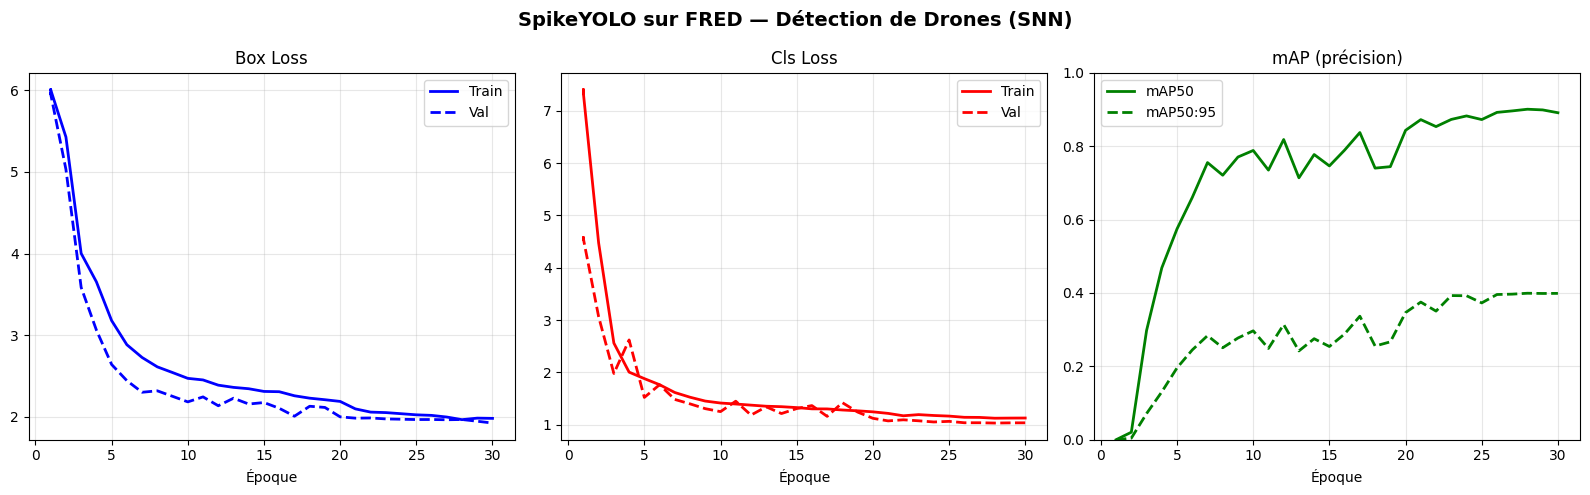


  Meilleur mAP50    : 0.9008
  Meilleur mAP50:95 : 0.3993
  À l'époque        : 31


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import os

csv_path = '/kaggle/working/SpikeYOLO/runs/fred_drone_spike/results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

epochs = df['epoch']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SpikeYOLO sur FRED — Détection de Drones (SNN)', fontsize=14, fontweight='bold')

# Box Loss
axes[0].plot(epochs, df['train/box_loss'], 'b-', linewidth=2, label='Train')
axes[0].plot(epochs, df['val/box_loss'],   'b--', linewidth=2, label='Val')
axes[0].set_title('Box Loss'), axes[0].set_xlabel('Époque')
axes[0].legend(), axes[0].grid(True, alpha=0.3)

# Cls Loss
axes[1].plot(epochs, df['train/cls_loss'], 'r-', linewidth=2, label='Train')
axes[1].plot(epochs, df['val/cls_loss'],   'r--', linewidth=2, label='Val')
axes[1].set_title('Cls Loss'), axes[1].set_xlabel('Époque')
axes[1].legend(), axes[1].grid(True, alpha=0.3)

# mAP
axes[2].plot(epochs, df['metrics/mAP50(B)'],    'g-',  linewidth=2, label='mAP50')
axes[2].plot(epochs, df['metrics/mAP50-95(B)'], 'g--', linewidth=2, label='mAP50:95')
axes[2].set_title('mAP (précision)'), axes[2].set_xlabel('Époque')
axes[2].set_ylim(0, 1), axes[2].legend(), axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*45}")
print(f"  Meilleur mAP50    : {df['metrics/mAP50(B)'].max():.4f}")
print(f"  Meilleur mAP50:95 : {df['metrics/mAP50-95(B)'].max():.4f}")
print(f"  À l'époque        : {df['metrics/mAP50(B)'].idxmax() + 1}")
print(f"{'='*45}")

---
## 🔲 Cellule 9 — Courbes manuelles (loss + mAP)

Si les graphiques auto ne s'affichent pas bien, on les recrée manuellement
à partir du CSV — c'est plus propre pour le rapport.

Ultralytics YOLOv8.0.197 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
snn_YOLOv8 summary: 621 layers, 13248643 parameters, 0 gradients, 78.1 GFLOPs
val: Scanning /kaggle/working/FRED_YOLO/labels/val.cache... 3032 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3032/3032 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 379/379 [02:28<00:00,  2.55it/s]
                   all       3032       3032      0.908      0.903      0.918      0.432
Speed: 0.3ms preprocess, 44.1ms inference, 0.0ms loss, 0.7ms postprocess per image
Saving /kaggle/working/SpikeYOLO/ultralytics/../tests/tmp/runs/detect/val/predictions.json...
Results saved to /kaggle/working/SpikeYOLO/ultralytics/../tests/tmp/runs/detect/val


         RÉSULTATS FINAUX — SpikeYOLO / FRED
  mAP50          : 0.9182  (91.82%)
  mAP50:95       : 0.4323  (43.23%)
  Précision      : 0.9084  (90.84%)
  Rappel         : 0.9029  (90.29%)
  F1 Score       : 0.9056


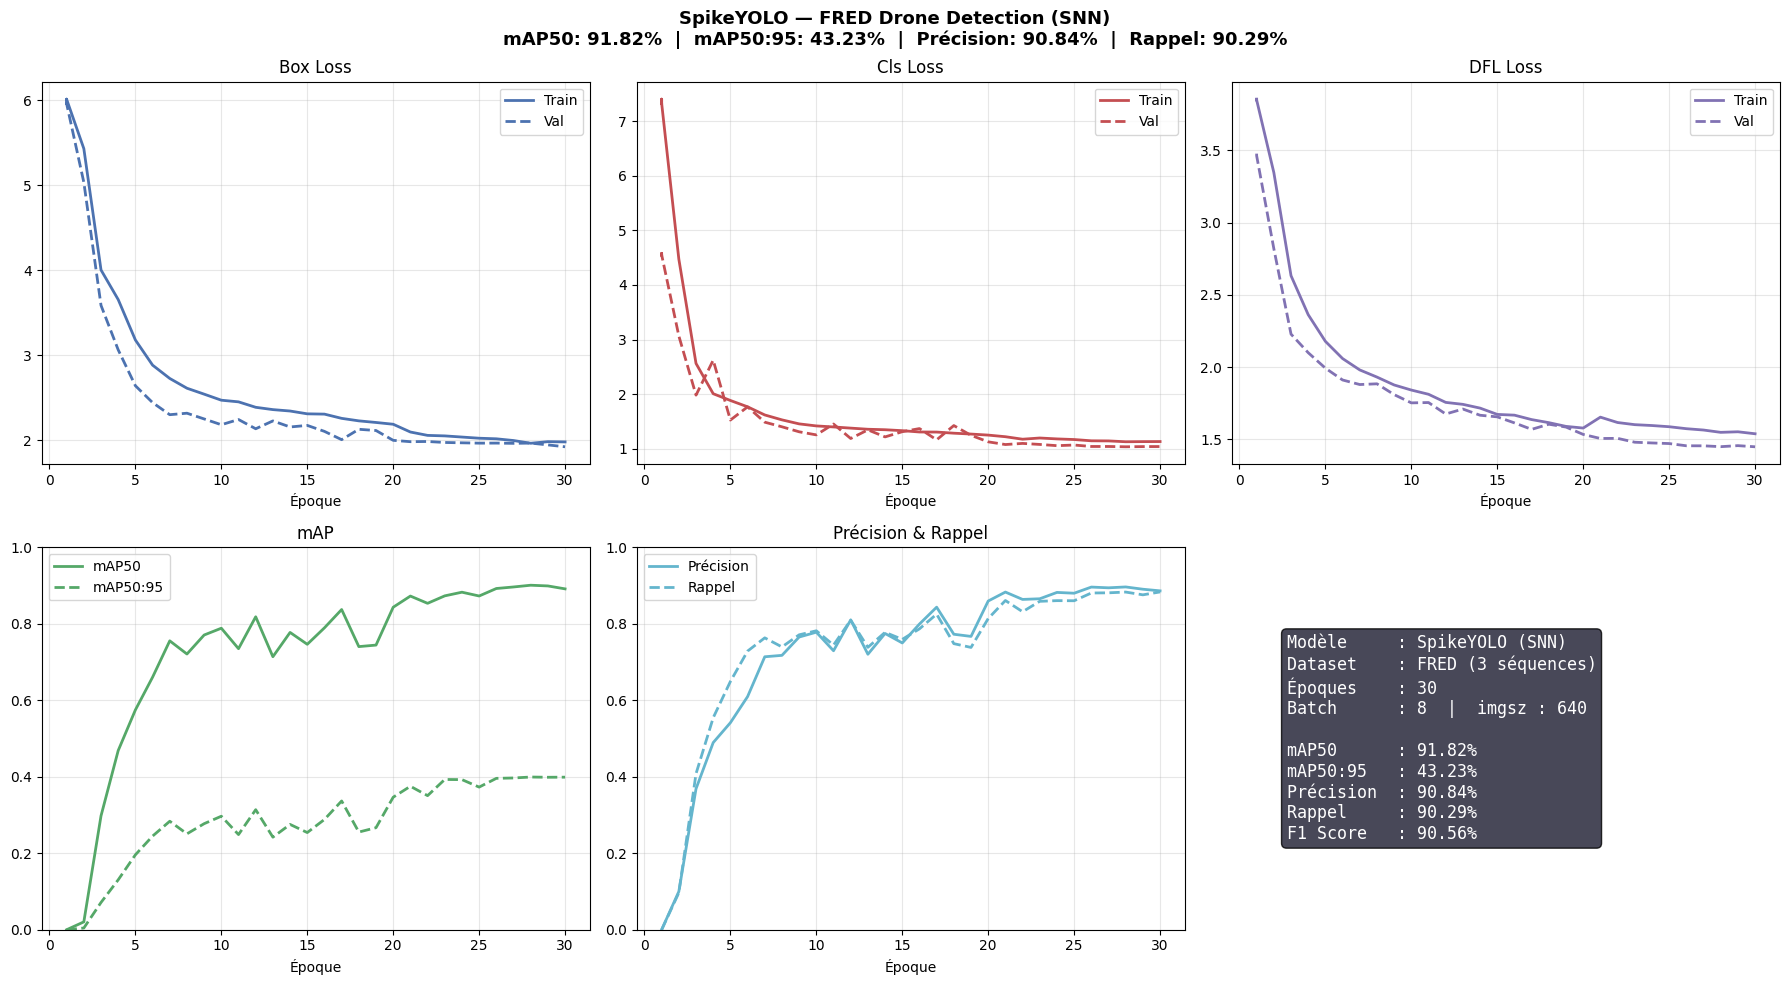

✅ Sauvegardé → /kaggle/working/final_metrics.png


In [65]:
import torch, os, json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
import torch
# Fix PyTorch 2.6 — autoriser le chargement des classes ultralytics
torch.serialization.add_safe_globals(['ultralytics.nn.tasks.DetectionModel'])

# Alternative si ça ne marche pas :
import torch.serialization
original_load = torch.load
torch.load = lambda *args, **kwargs: original_load(*args, **{**kwargs, 'weights_only': False})

# ── 1. Chargement du modèle ──────────────────────────────────────────
best_pt = '/kaggle/working/SpikeYOLO/runs/fred_drone_spike/weights/best.pt'
model = YOLO(best_pt)

# ── 2. Évaluation sur le set de validation ───────────────────────────
metrics = model.val(
    data='/kaggle/working/fred_drone.yaml',
    imgsz=640, batch=8, device=0,
    conf=0.25, iou=0.45,
    plots=True,  # génère confusion matrix, PR curve etc.
    save_json=True,
)

# ── 3. Affichage des métriques ───────────────────────────────────────
print("=" * 50)
print("         RÉSULTATS FINAUX — SpikeYOLO / FRED")
print("=" * 50)
print(f"  mAP50          : {metrics.box.map50:.4f}  ({metrics.box.map50*100:.2f}%)")
print(f"  mAP50:95       : {metrics.box.map:.4f}  ({metrics.box.map*100:.2f}%)")
print(f"  Précision      : {metrics.box.mp:.4f}  ({metrics.box.mp*100:.2f}%)")
print(f"  Rappel         : {metrics.box.mr:.4f}  ({metrics.box.mr*100:.2f}%)")
print(f"  F1 Score       : {2 * metrics.box.mp * metrics.box.mr / (metrics.box.mp + metrics.box.mr):.4f}")
print("=" * 50)

# ── 4. Courbes training depuis CSV ───────────────────────────────────
csv_path = '/kaggle/working/SpikeYOLO/runs/fred_drone_spike/results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SpikeYOLO — FRED Drone Detection (SNN)\nmAP50: {:.2f}%  |  mAP50:95: {:.2f}%  |  Précision: {:.2f}%  |  Rappel: {:.2f}%'.format(
    metrics.box.map50*100, metrics.box.map*100, metrics.box.mp*100, metrics.box.mr*100
), fontsize=13, fontweight='bold')

epochs = df['epoch']

# Box Loss
axes[0,0].plot(epochs, df['train/box_loss'], 'b-',  lw=2, label='Train')
axes[0,0].plot(epochs, df['val/box_loss'],   'b--', lw=2, label='Val')
axes[0,0].set_title('Box Loss'), axes[0,0].set_xlabel('Époque')
axes[0,0].legend(), axes[0,0].grid(True, alpha=0.3)

# Cls Loss
axes[0,1].plot(epochs, df['train/cls_loss'], 'r-',  lw=2, label='Train')
axes[0,1].plot(epochs, df['val/cls_loss'],   'r--', lw=2, label='Val')
axes[0,1].set_title('Cls Loss'), axes[0,1].set_xlabel('Époque')
axes[0,1].legend(), axes[0,1].grid(True, alpha=0.3)

# DFL Loss
axes[0,2].plot(epochs, df['train/dfl_loss'], 'm-',  lw=2, label='Train')
axes[0,2].plot(epochs, df['val/dfl_loss'],   'm--', lw=2, label='Val')
axes[0,2].set_title('DFL Loss'), axes[0,2].set_xlabel('Époque')
axes[0,2].legend(), axes[0,2].grid(True, alpha=0.3)

# mAP
axes[1,0].plot(epochs, df['metrics/mAP50(B)'],    'g-',  lw=2, label='mAP50')
axes[1,0].plot(epochs, df['metrics/mAP50-95(B)'], 'g--', lw=2, label='mAP50:95')
axes[1,0].set_title('mAP'), axes[1,0].set_xlabel('Époque')
axes[1,0].set_ylim(0, 1), axes[1,0].legend(), axes[1,0].grid(True, alpha=0.3)

# Précision & Rappel
axes[1,1].plot(epochs, df['metrics/precision(B)'], 'c-',  lw=2, label='Précision')
axes[1,1].plot(epochs, df['metrics/recall(B)'],    'c--', lw=2, label='Rappel')
axes[1,1].set_title('Précision & Rappel'), axes[1,1].set_xlabel('Époque')
axes[1,1].set_ylim(0, 1), axes[1,1].legend(), axes[1,1].grid(True, alpha=0.3)

# Résumé texte
axes[1,2].axis('off')
summary = (
    f"Modèle     : SpikeYOLO (SNN)\n"
    f"Dataset    : FRED (3 séquences)\n"
    f"Époques    : 30\n"
    f"Batch      : 8  |  imgsz : 640\n\n"
    f"mAP50      : {metrics.box.map50*100:.2f}%\n"
    f"mAP50:95   : {metrics.box.map*100:.2f}%\n"
    f"Précision  : {metrics.box.mp*100:.2f}%\n"
    f"Rappel     : {metrics.box.mr*100:.2f}%\n"
    f"F1 Score   : {2*metrics.box.mp*metrics.box.mr/(metrics.box.mp+metrics.box.mr)*100:.2f}%"
)
axes[1,2].text(0.1, 0.5, summary, transform=axes[1,2].transAxes,
               fontsize=12, verticalalignment='center', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.8), color='white')

plt.tight_layout()
plt.savefig('/kaggle/working/final_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé → /kaggle/working/final_metrics.png")

In [50]:
import shutil, os

# Copier les fichiers importants à la racine /kaggle/working/
shutil.copy(
    '/kaggle/working/SpikeYOLO/runs/fred_drone_spike/weights/best.pt',
    '/kaggle/working/best_spikeyolo_fred.pt'
)
shutil.copy(
    '/kaggle/working/training_curves.png',
    '/kaggle/working/training_curves_final.png'
)

print("Fichiers disponibles dans Output :")
for f in os.listdir('/kaggle/working/'):
    size = os.path.getsize(f'/kaggle/working/{f}') / 1e6
    print(f"  {f} — {size:.1f} MB")

Fichiers disponibles dans Output :
  training_curves.png — 0.1 MB
  SpikeYOLO — 0.0 MB
  best_spikeyolo_fred.pt — 107.1 MB
  FRED_YOLO — 0.0 MB
  .virtual_documents — 0.0 MB
  training_curves_final.png — 0.1 MB
  runs — 0.0 MB
  bbox_check.png — 0.0 MB
  fred_drone.yaml — 0.0 MB
  FRED — 0.0 MB
  fred_comparison.png — 0.2 MB


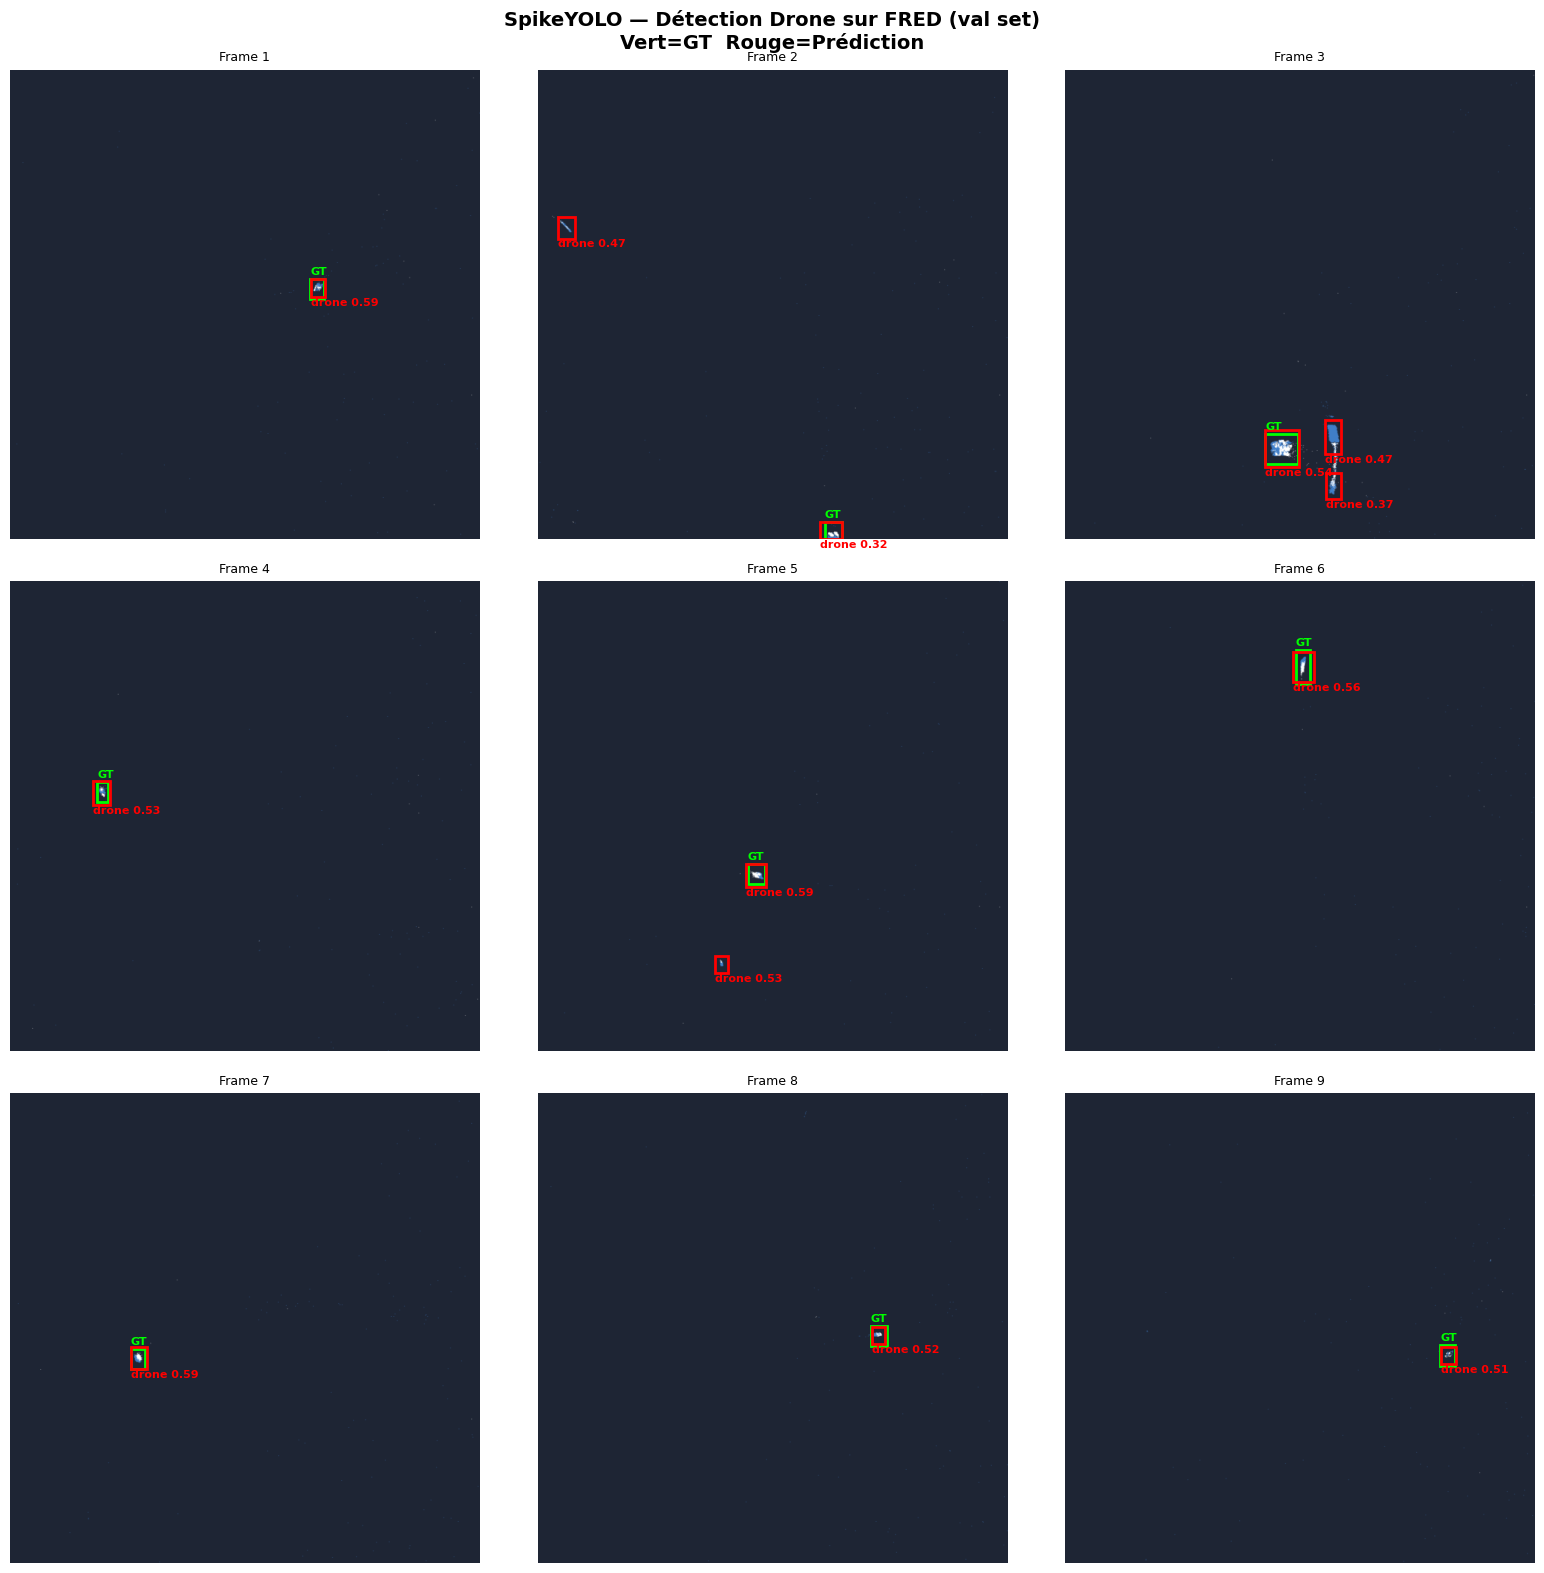

✅ Visualisation sauvegardée → /kaggle/working/predictions_visualization.png


In [66]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import os, glob

# Fix PyTorch 2.6
torch.load_original = torch.load
torch.load = lambda *args, **kwargs: torch.load_original(*args, **{**kwargs, 'weights_only': False})

from ultralytics import YOLO

# ── 1. Chargement du modèle ──────────────────────────────────────────
model = YOLO('/kaggle/working/SpikeYOLO/runs/fred_drone_spike/weights/best.pt')

# ── 2. Sélection de 9 images de validation ───────────────────────────
val_images = sorted(glob.glob('/kaggle/working/FRED_YOLO/images/val/*.png'))
samples = val_images[::len(val_images)//9][:9]  # 9 images réparties uniformément

# ── 3. Inférence + Visualisation ─────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 16))
fig.suptitle('SpikeYOLO — Détection Drone sur FRED (val set)\nVert=GT  Rouge=Prédiction', 
             fontsize=14, fontweight='bold')

for idx, (ax, img_path) in enumerate(zip(axes.flatten(), samples)):
    
    # Image originale
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img, cmap='gray')
    
    # Ground truth (label .txt)
    label_path = img_path.replace('images/val', 'labels/val').replace('.png', '.txt')
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                _, xc, yc, w, h = map(float, line.strip().split())
                W, H = img.size
                x1 = (xc - w/2) * W
                y1 = (yc - h/2) * H
                rect = patches.Rectangle((x1, y1), w*W, h*H,
                                          linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-5, 'GT', color='lime', fontsize=8, fontweight='bold')
    
    # Prédiction
    results = model(img_path, conf=0.25, iou=0.45, verbose=False)
    for box in results[0].boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y2+12, f'drone {conf:.2f}', color='red', fontsize=8, fontweight='bold')
    
    ax.set_title(f'Frame {idx+1}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/predictions_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisation sauvegardée → /kaggle/working/predictions_visualization.png")

---
## 🔲 Cellule 10 — Bilan final

Résumé de tout le projet.

In [51]:
import os

run_dir = '/kaggle/working/runs/fred_drone_spike'
weights_best = os.path.join(run_dir, 'weights', 'best.pt')
weights_last = os.path.join(run_dir, 'weights', 'last.pt')

print("=" * 55)
print("     ✅ BILAN ÉTAPE 3 — ENTRAÎNEMENT TERMINÉ")
print("=" * 55)

print(f"""
Architecture  : SpikeYOLO (ECCV 2024)
Framework     : SpikingJelly + PyTorch
Dataset       : FRED (Florence RGB-Event Drone Dataset)
Modalité      : Event Frames (caméra événementielle)
Classes       : 1 (drone)
""")

print("Fichiers sauvegardés :")
print(f"  Best model  : {'✅' if os.path.exists(weights_best) else '❌'} {weights_best}")
print(f"  Last model  : {'✅' if os.path.exists(weights_last) else '❌'} {weights_last}")
print(f"  Courbes     : {'✅' if os.path.exists(run_dir+'/results.png') else '❌'} {run_dir}/results.png")
print(f"  CSV metrics : {'✅' if os.path.exists(run_dir+'/results.csv') else '❌'} {run_dir}/results.csv")

print(f"""
{'='*55}
🚀 Prochaines étapes possibles :
   → Augmenter le nombre d'époques (50, 100...)
   → Télécharger plus de séquences FRED
   → Tester la détection sur de nouvelles images
   → Comparer avec un modèle ANN (YOLOv8 classique)
{'='*55}
""")

     ✅ BILAN ÉTAPE 3 — ENTRAÎNEMENT TERMINÉ

Architecture  : SpikeYOLO (ECCV 2024)
Framework     : SpikingJelly + PyTorch
Dataset       : FRED (Florence RGB-Event Drone Dataset)
Modalité      : Event Frames (caméra événementielle)
Classes       : 1 (drone)

Fichiers sauvegardés :
  Best model  : ❌ /kaggle/working/runs/fred_drone_spike/weights/best.pt
  Last model  : ❌ /kaggle/working/runs/fred_drone_spike/weights/last.pt
  Courbes     : ❌ /kaggle/working/runs/fred_drone_spike/results.png
  CSV metrics : ❌ /kaggle/working/runs/fred_drone_spike/results.csv

🚀 Prochaines étapes possibles :
   → Augmenter le nombre d'époques (50, 100...)
   → Télécharger plus de séquences FRED
   → Tester la détection sur de nouvelles images
   → Comparer avec un modèle ANN (YOLOv8 classique)



In [53]:
import os

weights_path = '/kaggle/working/SpikeYOLO/runs/fred_drone_spike/weights'
print("Contenu du dossier weights :")
for f in os.listdir(weights_path):
    size = os.path.getsize(f'{weights_path}/{f}') / 1e6
    print(f"  {f} — {size:.1f} MB")

Contenu du dossier weights :
  epoch5.pt — 107.2 MB
  last.pt — 107.1 MB
  epoch20.pt — 107.2 MB
  epoch10.pt — 107.2 MB
  epoch25.pt — 107.2 MB
  best.pt — 107.1 MB
  epoch15.pt — 107.2 MB


In [55]:
from IPython.display import FileLink, display

display(FileLink('best_spikeyolo_fred.pt'))
display(FileLink('training_curves_final.png'))

/kaggle/working/SpikeYOLO/best_spikeyolo_fred.pt

/kaggle/working/SpikeYOLO/training_curves_final.png

In [56]:
from IPython.display import FileLink, display

display(FileLink('/kaggle/working/SpikeYOLO/runs/fred_drone_spike/weights/best.pt'))
display(FileLink('/kaggle/working/training_curves_final.png'))

/kaggle/working/SpikeYOLO/runs/fred_drone_spike/weights/best.pt

/kaggle/working/training_curves_final.png


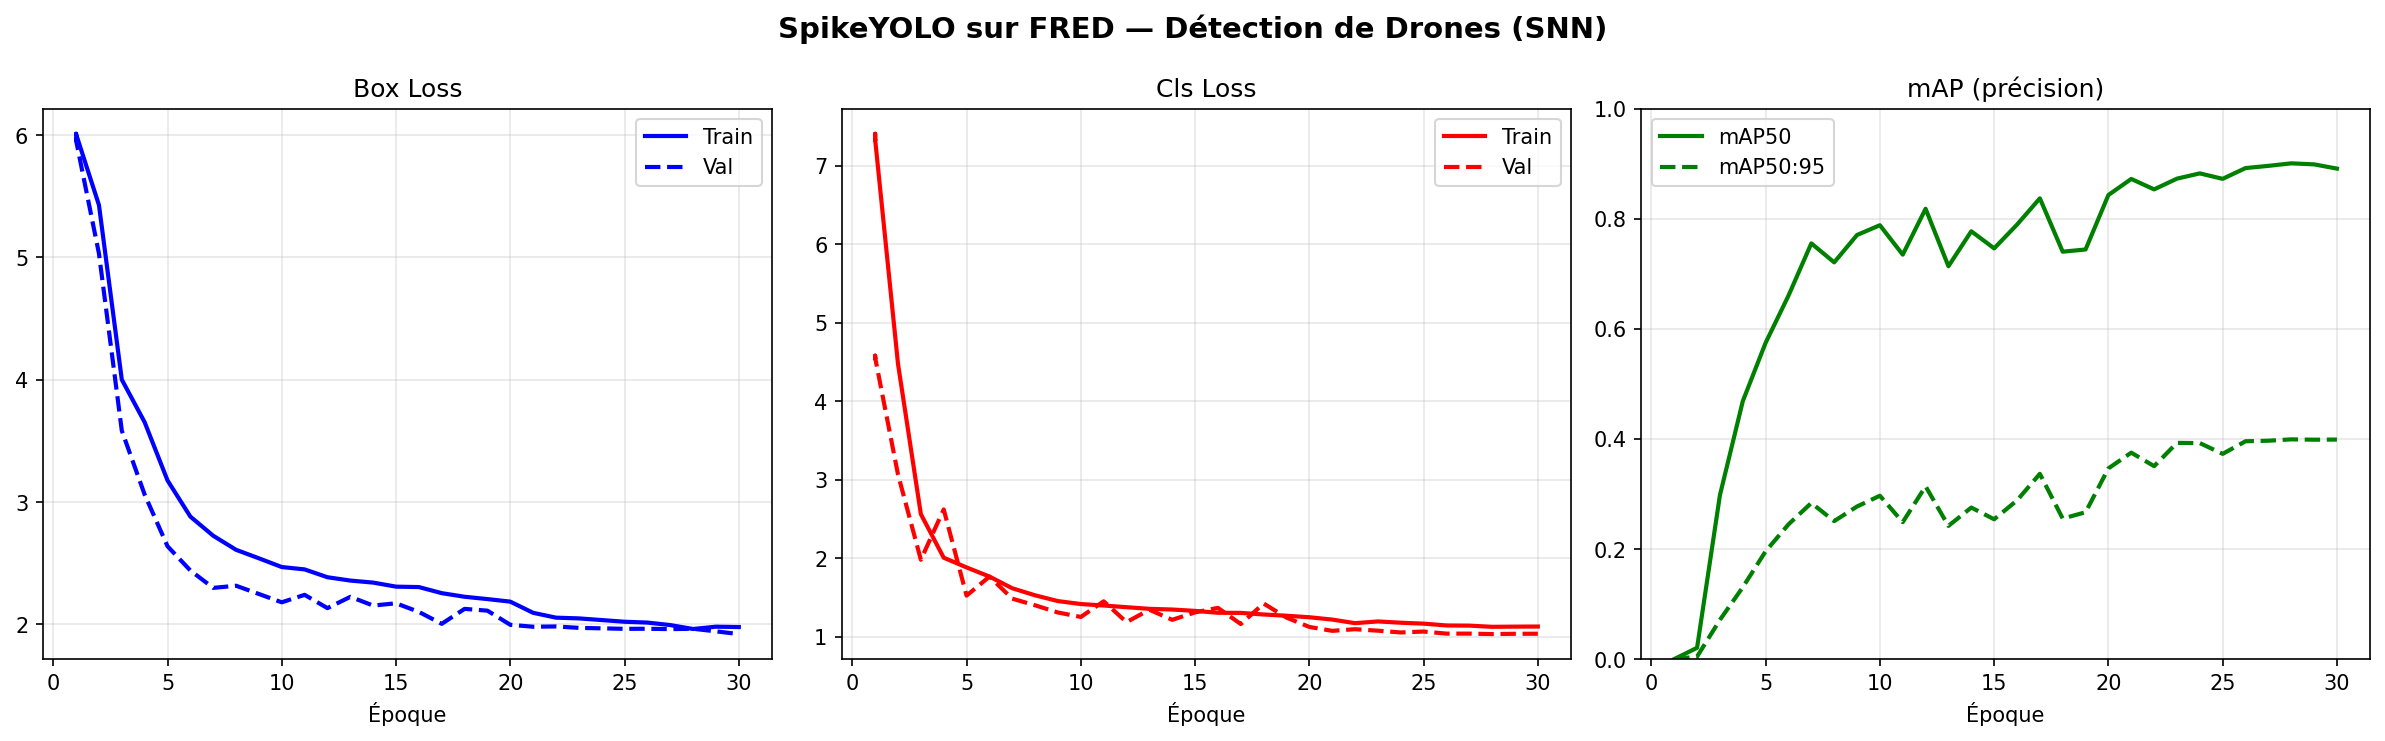

In [57]:
# Copie vers /kaggle/working/ et ajoute comme dataset output
import shutil

# Les fichiers sont déjà dans /kaggle/working/
# Il faut les ajouter comme "output dataset" dans les settings Kaggle

# Pour l'instant, télécharge via cette astuce :
import base64, os
from IPython.display import HTML

with open('/kaggle/working/training_curves_final.png', 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

html = f'<a href="data:image/png;base64,{b64}" download="training_curves.png">⬇️ Télécharger training_curves.png</a>'
display(HTML(html))